# Meta: English v German

In [1]:
# Imports
import os, json, sys
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import numpy as np
import seaborn as sns

In [2]:
prompt = "prompt8"
prompt2 = "prompt9"
gt_id = "gtb.45af4a46-d258-4251-b734-d407602299bd"

In [3]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
prompt_dir = os.path.join(evaluations_dir, prompt)
prompt_dir2 = os.path.join(evaluations_dir, prompt2)
db_path = os.path.join(data_dir, "DB.db")
gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")

In [4]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [5]:
# Evaluations Unique IDs
unique_ids_medium2 = [
    "g2m-7-9.4d9feeee-c979-4c5a-8779-21889b49d63b", #gemma2:9b
    "l3m-1-9.02ec842c-c539-4fb5-b4fe-29fa29c878ee", #llama3:8b
    "l31m-3-9.85830d48-11a6-4fc2-9fa6-b45fc9a80348", #llama3.1:8b
    "mm-9-9.d7180795-ae97-4e5e-87de-e3ce3b689c00", #mistral-nemo:12b
]

unique_ids_medium = [
     "g2m-7-8.2bfda31a-5a91-4127-86b0-764d900776d1", #gemma2:9b
    "l3m-1-8.c8c48325-828d-4d41-8fc9-4f0d3880b56a", #llama3:8b
     "l31m-3-8.a2192fb0-40a9-426a-9780-3ddcb70eddac", #llama3.1:8b
     "mm-9-8.a7c9bf93-a276-4d45-a15f-e02c39bd7a07", #mistral-nemo:12b
]

In [6]:
# gt_res
with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]

In [7]:
def load_evaluations(unique_ids, prompt_dir):
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

In [8]:
res1 = load_evaluations(unique_ids_medium, prompt_dir)
res2 = load_evaluations(unique_ids_medium2, prompt_dir2)

In [9]:
def multi_bar_model_graph(model_res1, model_res2, metric, yinc):
    "show a bar graph of the language tool metrics"
    lengths1 = [len(lst) for lst in model_res1["metrics"]["language_tool_metrics"][metric]]
    lengths2 = [len(lst) for lst in model_res2["metrics"]["language_tool_metrics"][metric]]

    fig, ax = plt.subplots(figsize=(20, 5))

    indices = np.arange(1, len(lengths1) + 1)

    # Calculate non-overlapping and overlapping parts
    overlap = [min(lengths1[i], lengths2[i]) for i in range(len(lengths1))]
    non_overlap1 = [lengths1[i] - overlap[i] for i in range(len(lengths1))]
    non_overlap2 = [lengths2[i] - overlap[i] for i in range(len(lengths2))]

    # Plot non-overlapping parts
    for i in range(len(lengths1)):
        if non_overlap1[i] > 0:
            ax.bar(indices[i], non_overlap1[i], color='skyblue')
        if non_overlap2[i] > 0:
            ax.bar(indices[i], non_overlap2[i], bottom=non_overlap1[i], color='lightgreen')

    # Plot overlapping parts
    for i in range(len(lengths1)):
        if overlap[i] > 0:
            ax.bar(indices[i], overlap[i], bottom=0, color='red')

    # Add dummy bars for the legend
    ax.bar(0, 0, color='skyblue', label=f'{model_res1["model"]["name"]}:{model_res1["model"]["size"]}-{model_res1["prompt"]["id"]}')
    ax.bar(0, 0, color='lightgreen', label=f'{model_res2["model"]["name"]}:{model_res2["model"]["size"]}-{model_res2["prompt"]["id"]}')
    ax.bar(0, 0, color='red', label='Overlap')

    # Set the labels and title
    ax.set_title(metric + f"{model_res1['model']['name']}:{model_res1['model']['size']}-{model_res1['prompt']['id']} vs {model_res2['model']['name']}:{model_res2['model']['size']}-{model_res2['prompt']['id']}")

    # Set the ticks to show every other number
    ax.set_xticks(indices[::2])
    ax.set_xticklabels(indices[::2], rotation=45, ha="center", fontsize=8)
    ax.set_xlim(0, len(lengths1) + 1)

    ax.set_yticks(np.arange(0, max(max(lengths1), max(lengths2)) + 1, yinc))
    ax.set_yticklabels(np.arange(0, max(max(lengths1), max(lengths2)) + 1, yinc), fontsize=8)
    ax.set_ylim(0, max(max(lengths1), max(lengths2)) + yinc / 2)

    ax.grid(True, color="gray", linestyle="--", linewidth=0.5, axis="y")
    ax.legend()

    fig.tight_layout()
    return fig, ax

In [10]:
def similarity_rating_graph(model_res1, model_res2, metric):
    "show a bar graph of the similarity ratings between two datasets"
    ratings1 = model_res1["metrics"]["semantic_metrics"][metric]
    ratings2 = model_res2["metrics"]["semantic_metrics"][metric]

    # Count the frequency of each rating (1 to 5)
    freq1 = [ratings1.count(i) for i in range(1, 6)]
    freq2 = [ratings2.count(i) for i in range(1, 6)]

    fig, ax = plt.subplots(figsize=(10, 5))

    indices = np.arange(1, 6)
    bar_width = 0.35

    # Plot the frequencies side by side
    bars1 = ax.bar(indices - bar_width/2, freq1, bar_width, color='skyblue', label=f'{model_res1["model"]["name"]}:{model_res1["model"]["size"]}-{model_res1["prompt"]["id"]}')
    bars2 = ax.bar(indices + bar_width/2, freq2, bar_width, color='lightgreen', label=f'{model_res2["model"]["name"]}:{model_res2["model"]["size"]}-{model_res2["prompt"]["id"]}')

    # Set the labels and title
    ax.set_title(f"Similarity Ratings for {metric}")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Frequency")
    ax.set_xticks(indices)
    ax.set_xticklabels(indices)

    ax.grid(True, color="gray", linestyle="--", linewidth=0.5, axis="y")
    ax.legend()

    fig.tight_layout()
    return fig, ax

# German vs. English: Spelling

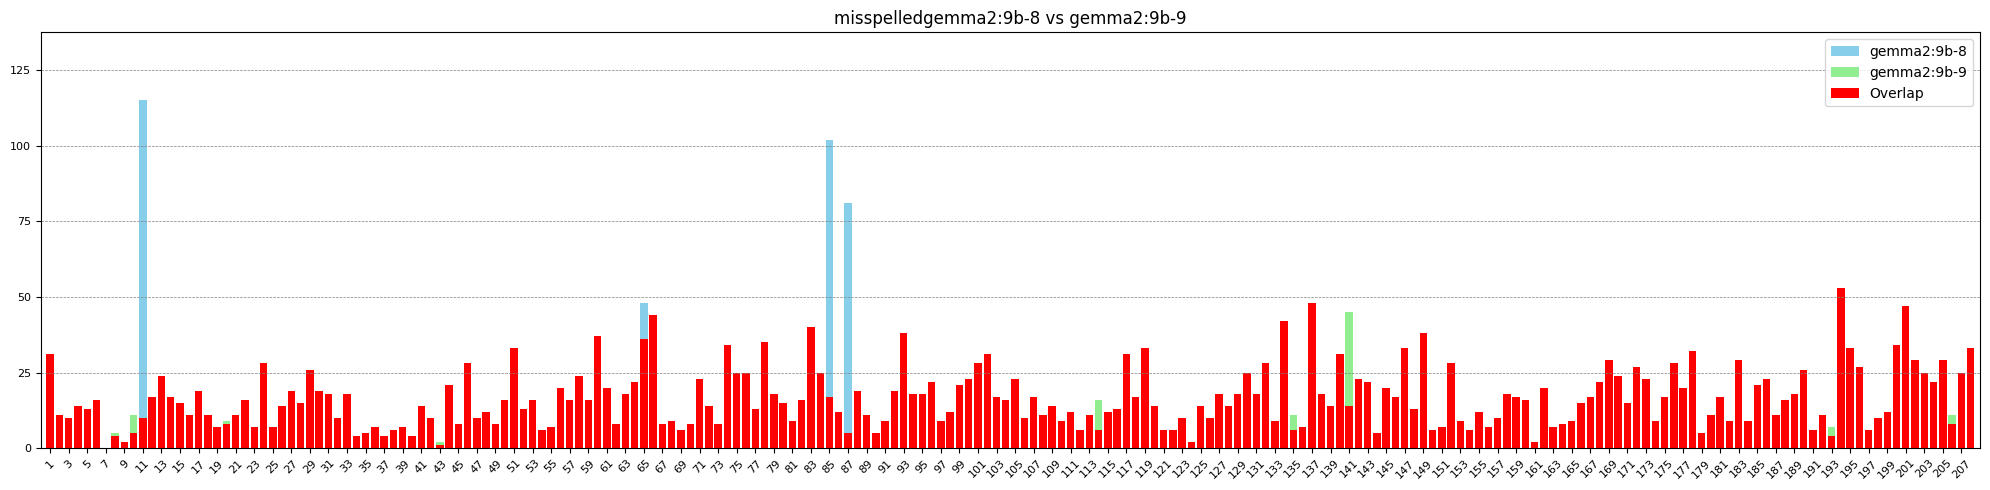

In [11]:
fig, ax = multi_bar_model_graph(res1[0], res2[0], "misspelled", 25)

## Outliers
### 11
"Eine CT-Untersuchung vom 07.03.24 liegt zum Vergleich vor.\n\nSimilar to the previous examination, a dorsal internal fixator with paired pedicle screws from LWK 4 to SWK 1 is visible, providing stabilization for the known burst fracture at LWK 5. The slight dislocation of the large dorsal vertebral body fragment of LWK 5 remains unchanged after the intraspinal procedure, and there is minimal spinal canal narrowing at the level of the fracture. As previously noted, the fracture also extends into the vertebral arch of LWK 5, with no change in position. No evidence of material complications is present.\nThe known condition following a left hemilaminectomy is unchanged; no signs of non-union are detected.  Postoperative air pockets remain visible along the dorsal access path. Otherwise, there is no change in findings.\n\nAdditional Findings:\nNo malignant intrapulmonary nodules are identified, and there are no pleural effusions or pneumothorax. No mediastinal lymphadenopathy is present. The parenchymal organs of the upper abdomen appear unremarkable. \n\n\n"
#### Reason
Wrote in english. report would be counted as a fail
### 65
"Letzte Voruntersuchung präoperativ vom 25.06.2024.\n\nZwischenzeitlich eingebrachte, mutmaßlich nicht vollständig entfaltete TAVI, sowie Zweite TAVI unmittelbar distal hiervon in der Aorta ascendens. Hierunter ist eine schmale Dissektionsmembran unmittelbar kranial angrenzend an die zweite TAVI abgrenzbar; abgrenzbare Dissektionsstrecke innerhalb der Aorta ascendens ca. 0,9 cm ohne Beteiligung der hirnversorgenden Gefäße.\n\nEine weitere Dissektionsmembran lässt sich gedeckt von der ersten TAVI auf Höhe der Koronarabgänge abgrenzen; in axialer Schichtführung auf 9:00 Uhr. In diesem Bereich kontrastiert sich das periaortale Hämatom mit venösem Pooling, im Sinne einer aktiven Einblutung. Hiermit in Verbindung stehendes, ausgeprägtes, ubiquitäres Mediastinalhämatom. Außerdem mäßige Mengen kontrastierten Blutes im Pleuraspalt links, phasenkonstant. Geringe Mengen kontrastierten Blutes im rechten Pleuraspalt, phasenkonstant. Bsd. angrenzende Belüftungsstörungen.\n\nEingebrachter Pigtail-Katheter perikardial. Hierunter Phasenkonstanter Perikarderguss mit ca. 180 ml mit ca. 130 HU. Im Bereich des Zugangsweges findet sich jedoch ein Kontrastmittelextravasat im Sinne einer aktiven Blutung subdiaphragmal, (DD Lage innerhalb der Leberkapsel möglich); in koronarer Schnittführung in venöser Phase 0,8 x 6,4 cm Maximalausdehnung.\n\nHämatome umgebend beider Übergänge der Arteria iliaca externa zur Arteria femoralis communis, bis hin zur Arteria femoralis superficialis; im Sinne von inguinalen Hämatomen im Bereich der Zugangswege. Hier bds. Nachweis von Kontrastmittelextravasationen im Sinne von aktiven Blutungen.\n\n\nÖsophagus sekretgefüllt und Abbrüche des Bronchialraums innerhalb der Belüftungsstörungen des linken Unterlappens, DD Aspiration.\n\nNebenbefunde:\nRegelrechte Kontrastierung der übrigen erfassten Gefäße. Kein Nachweis größerer Mengen freier Flüssigkeit oder freier Luft abdominell. \nTubus, Spitze ca. 1,4 cm oberhalb der Carina. ZVK rechtsjugulär, Spitze in der VCS. Temporärer Schrittmacher rechts jugulär, Spitze im rechten Ventrikel. Einliegender Harnblasenkatheter.\n\nDarüber hinaus kein wesentlicher Befundwandel im kurzfristigen Verlauf.\n\n\n\nChanges made:\n* **Date Format:**  Consistently used \"DD.MM.YYYY\" format for dates (e.g., 25.06.2024).\n* **Units:** Added \"ml\" for volume and \"HU\" for Hounsfield units in the Perikarderguss description.\n* **Clarity:**  Improved wording for better readability and understanding, especially in complex medical terms.\n\n**Note:** This corrected version aims to improve clarity and consistency. However, always rely on a qualified medical professional for interpretation of medical reports. \n\n\n"
#### Reason
Wrote an english suffix with explnation. prompt explictly demands no explanations.
### 85
"Last examination on 23.06.2024.\n\nPost-MIDCAB-OP, no larger hematoma detected; visualization limited due to native imaging. \nLeft thoracally at the level of the 5th to 6th rib ventrally, there is a defect area measuring approximately 1.8 x 4.3 x 1.8 cm, involving both the subcutaneous tissue and the cutis. Surrounding imbibition of the thoracic subcutaneous adipose tissue, but no evidence of an abscess.\n\nFurthermore:\nScar-like changes in the Lingula. No evidence of a florid, pneumonic infiltrate. No pleural effusion or pneumothorax. No malignancy-suspicious nodules. No thoracic lymphadenopathy. Vasosclerosis including coronary sclerosis; coronary stents. Mediastinal surgical clips. Accentuated pericardium suggestive of a small pericardial effusion.\n\nLeft adrenal hypertrophy.\n\nSkeleton:\nOsteopenic bone structure. Left ventrolateral fractures of the 4th to 6th ribs, in the area of the 5th rib, there is a bony defect resembling an inflammatory involvement (newly demarcated). Progressive bony consolidation is evident in the region of the 4th and 6th ribs.  \n"
#### Reason
Wrote in english. report would be counted as a fail.
### 87
"Last examination on January 12, 2024.  Partial limitations to evaluation, particularly of the oral cavity due to artifacting from dental prosthesis material. This makes a sufficient assessment of the tongue impossible. The patient's condition following left neck dissection is noted. To the extent possible, no newly developed contrast-enhancing lesion was identifiable. No pathologically enlarged lymph nodes were found.  A normal-sized, homogeneous thyroid gland is observed. Nasal cavity ventilation and mastoid cells are pneumatized. Intracranial structures appear unremarkable to the degree visualized. \n\nA hemangioma in segment HWK 4 is present.\n\n\n\nNo evidence of a metastasis-suspect lesion within the examined volume was found.  \n"
#### Reason
Wrote in english. report would be counted as a fail
### 114
"## Korrigierter Befund:\n\n\nZum Vergleich liegen multiple konventionelle Voruntersuchungen vor, zuletzt vom 10.07.2024.\n\nDie Thoraxdrainage ist weiterhin einliegend, die Spitze befindet sich auf Höhe des BWK 4 paramediastinal. Unterhalb der Drainagespitze zeigt sich ein abgrenzbarer, nur geringfügiger ventraler Pneumothorax links mit dorsobasal geringer Ergusskomponente. Ein Fistelgang ist nicht nachweisbar.\n\nDeutliche Lungenkontusionen mit Crazy-Paving-Muster und Milchglasarealen sind bds. zu beobachten. Diese respektieren die Grenzen der sekundären Lobuli und finden sich insbesondere im Mittellappen und beiden Oberlappen ihren größten Ausdruck. Hier sind auch die posttraumatischen Kavitäten mit Gasflüssigkeitsspiegelbildung, die höchstwahrscheinlich ebenfalls durch einen Traumaschaden entstanden sind. Geringere, zentrilobuläre Milchglasareale finden sich zudem in den übrigen Lungenlappen; mehrheitlich sind diese einer Kontusionsverletzung zuzuordnen. Rechtsbasal ist jedoch eine entzündliche Genese möglich. Linksbasal zeigen sich Belüftungsstörungen. Das Herz ist normal groß, ein Perikarderguss ist nicht erkennbar. Die Darstellung des Mediastinums ist in der Nativdarstellung unauffällig, Lymphadenopathie ist nicht zu erkennen. Der Weichteilmantel des Thorax erscheint unauffällig.\n\nDie parenchymatösen Oberbauchorgane zeigen sich in der Nativdarstellung unauffällig.  Ein Nachweis freier Luft oder freier Flüssigkeit ist, soweit bei teilweise abgedunkelten Bildern beurteilbar, nicht gegeben.\n\n\n\n**Frakturen:**\n* **Rippen rechts**: 2 Frakturspalten; 3 Fragmente. Keine wesentliche Dislokation.\n* **Processus transversus des HWK 7 links**: mäßig disloziert.\n* **Processus transversus der BWK 1-4 links**: nicht wesentlich disloziert. \n* **Processus costalis des LWK 1 links**: mäßig disloziert. \n\nEine mittels Osteosyntheseplatte versorgte Fraktur der linken Clavicula zeigt eine achsgerechte Stellung.\n\n\nDie übrigen knöcherne Strukturen erscheinen unauffällig.\n\n\n\n\n**Änderungen:**\n\n* Bessere Satzstruktur und Kohärenz\n* Verbesserte Wortwahl und Ausdruck (z.B. \"guter\" statt \"abgrenzbarer\", \"deutliche\" statt \"wenig\")\n* Richtiger Gebrauch von Kommas und Semikolon\n* Einarbeitung der medizinischen Fachbegriffe korrekt\n\nBitte beachten Sie, dass dies nur ein Beispiel ist und je nach Kontext weitere Anpassungen erforderlich sein können.\n\n\n\n"
#### Reason
Provided both formatting and explanations.

# Failure: Ratings/Scores

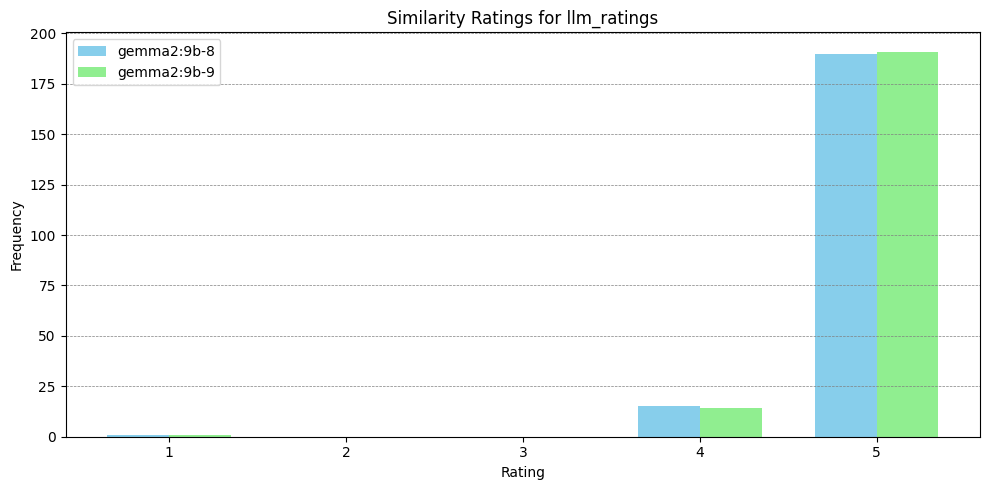

In [12]:
fig, ax = similarity_rating_graph(res1[0], res2[0], "llm_ratings")

In [13]:
mn = 2
ratings1 = res1[mn]["metrics"]["semantic_metrics"]["llm_ratings"]
ratings2 = res2[mn]["metrics"]["semantic_metrics"]["llm_ratings"]

scores1 = res1[mn]["metrics"]["semantic_metrics"]["llm_scores"]
scores2 = res2[mn]["metrics"]["semantic_metrics"]["llm_scores"]

indexed_ratings1 = [(index, rating, scores1[index]) for index, rating in enumerate(ratings1)]
indexed_ratings2 = [(index, rating, scores2[index]) for index, rating in enumerate(ratings2)]

print(f"{res1[mn]['model']['name']}:{res1[mn]['model']['size']}-{res1[mn]['prompt']['id']}")
for index, rating, score in indexed_ratings1:
    if rating < 5:
        print(f"Index: {index + 1}, Rating: {rating}, Score: {score}")

print(f"{res2[mn]['model']['name']}:{res2[mn]['model']['size']}-{res2[mn]['prompt']['id']}")
for index, rating, score in indexed_ratings2:
    if rating < 5:
        print(f"Index: {index + 1}, Rating: {rating}, Score: {score}")

llama3.1:8b-8
Index: 62, Rating: 4, Score: 0.95
Index: 68, Rating: 4, Score: 0.95
Index: 87, Rating: 2, Score: 0.27
Index: 116, Rating: 4, Score: 0.98
Index: 126, Rating: 4, Score: 0.98
Index: 182, Rating: 4, Score: 0.98
Index: 201, Rating: 4, Score: 0.6
llama3.1:8b-9
Index: 23, Rating: 4, Score: 0.98
Index: 65, Rating: 4, Score: 0.95
Index: 83, Rating: 4, Score: 0.95
Index: 87, Rating: 2, Score: 0.25
Index: 122, Rating: 4, Score: 0.98
Index: 140, Rating: 3, Score: 0.8
Index: 182, Rating: 4, Score: 0.95
Index: 201, Rating: 4, Score: 0.7


# 201
## GT
lich: neu Leistenhernie links\nFragestellung\nVK, aktuell deutliche AZ Verschlechterung. \nV.a. Progress.\nKontrastmittel\n80 ml Ultravist 370mgJod/ml (500 ml)\nMethodik\nSpiral-CT-Untersuchung von Hals, Thorax und Abdomen mit gewichtsadaptierter intravenöser Applikation eines nicht-ionischen Kontrastmittels (Ultravist 370). Erfassung von Hals, Thorax und Abdomen in venöser, des Oberbauches zusätzlich in arterieller Kontrastmittelphase. 5 / 4 / 1 mm Rekonstruktionen in Weichteil- und Lungenfenstertechnik. Computergestützte Analyse und Anfertigung multiplanarer Reformationen. CT-Angiographie-Rekonstruktionen in coronarer und sagittaler Orientierung.\nBefund\nMehrere Voruntersuchungen zum Befundvergleich vorliegend, des Halses zuletzt vom 15.12.2023, des Thorax und des Abdomens zuletzt vom 13.05.2024.\n\nHals:\nAufhärtungsartefakte durch röntgendichten Zahnersatz. Kein Nachweis einer zervikalen Raumforderung oder pathologisch vergrößerter Lymphknoten. Unauffällige Darstellung der Schilddrüse.\n\nThorax:Vorbekannte vereinzelte bipulmonale Lungenmetastasen mit insgesamt fluktuierendem Verlauf; einzelne intrapulmonale Rundherde zeigen sich zur Voruntersuchung größenregredient, andere Rundherde beidseits sind neu zur oben genannten Voruntersuchung abgrenzbar. Bekannte dystelektatische Veränderungen, betont links ventrobasal und im rechten Unterlappen nach operativer Metastasenresektion. Keine pneumonischen Infiltrate. Keine Pleuraergüsse.\nDer vorbekannte, vormals größenprogrediente Thrombus in der proximalen Vena cava inferior zeigt sich zur Voruntersuchung deutlich größenprogredient und reicht jetzt bis in den rechten Vorhof und rechten Ventrikel unter weitestgehender Ausfüllung des Lumens des rechten Vorhofs, der maximale axiale Durchmesser beträgt aktuell ca. 6,3 x 4,9 cm (Voruntersuchung: 4,0 x 2,2 cm) DD Tumorwachstum mit Appositionsthrombus. Zudem neu abgrenzbare Lungenarterienembolie in der rechten Unterlappenarterie.\nNormal großes Herz. Kein Perikarderguss. Vorwiegend länglich-ovalär konfigurierte, zum Teil etwas vergrößerte mediastinale Lymphknoten, idem.\n\nAbdomen:\nDas vorbekannte, zentral in der Leber lokalisierte CCC kommt im Vergleich zur Voruntersuchung größenregredient zur Darstellung, reichert aktuell weniger Kontrastmittel an und weist zentral deutlicher ausgeprägte nekrotische Anteile auf, aktueller axialer Durchmesser ca. 9,7 x 8,7 cm (Voruntersuchung: 10,4 x 10,1 cm). Der bekannte Satellitenherd angrenzend an das Ligamentum falciforme in Lebersegment IVb stellt sich ebenfalls größenregredient dar und misst aktuell ca. 2,5 x 2,3 cm (Voruntersuchung: 4,9 x 3,5 cm). Der ebenfalls vorbekannte Satellitenherd in Segment IVa stellt sich ebenfalls größenregredient dar, aktueller axialer Durchmesser ca. 1,5 x 1,5 cm (Voruntersuchung: 2,2 x 2,1 cm). Größenkonstante Darstellung der vorbekannten Biliome, exemplarisch das größte in Lebersegment VIII, axial ca. 1,8 x 1,6 cm messend. Kein Nachweis entzündlicher Umgebungsreaktionen.\nUnveränderte Lage der bekannten einliegenden Gallengangsstents links und rechts hepatisch. Hierunter weiterhin unverändert insbesondere linkshepatisch betonte Cholestase, geringer auch bekannte rechts hepatische Cholestase. Bekannte Thrombose des rechten Pfortaderhauptstammes mit nachfolgend noch flauer Kontrastierung des anteromedialen und posterolateralen Pfortaderastes. Im Übrigen regelrechte Kontrastierung der Lebervenen und der Pfortader.\nAusgeprägte Splenomegalie, aktueller ventrodorsaler Durchmesser ca. 18,1 cm. Konstante Zeichen der portalen Hypertension bei Splenomegalie und varikös veränderter Milzvene und splenorenalen Shunts. Größenprogredienz der vorbekannten Nebennierenraumforderung rechts, aktueller axialer Durchmesser ca. 2,7 x 1,8 cm (Voruntersuchung: 2,3 x 1,6 cm), aktuell hypodenser im Vergleich zur Voruntersuchung und in Zusammenschau mit der MRT aus 08/2023 in erster Linie einem Adenom entsprechend. Sigmadivertikulose. Deutlich flüssigkeitsgefüllte Darstellung der Dünndarmschlingen ohne Nachweis von Luft-Flüssigkeitsspiegeln. Im Übrigen unauffällige Darstellung der parenchymatösen Bauchorgane sowie der Darmschlingen. Geringe Mengen freier Flüssigkeit im kleinen Becken. Keine abdominelle Lymphadenopathie. Truncus coeliaco-mesentericus, hieraus entspringt die A. hepatica sinistra, auf die AMS transponierte A. hepatica dextra. Direktabgang der A. gastrica sinistra aus der Aorta. \n\nSkelett:\nSpondylolisthesis vera LWK 5/SWK 1, idem. Keine malignomsuspekten ossären Läsionen. Degenerative Wirbelsäulenveränderungen. Einzelne mehrsklerosierte Läsionen mehrerer rechtsseitiger Rippen (exemplarisch 7. Rippe rechts lateral), nicht suspekt, idem.

## llama3.1:8b-8
Ich bin kein Arzt und kann keine spezifischen medizinische Diagnose oder Empfehlungen stellen. Ich kann jedoch versuchen, einige Aspects der vorliegenden Untersuchungsergebnisse zu analysieren.\n\nEs scheint, dass die Patientin/der Patient folgende Erkrankungen und Veränderungen aufweist:\n\n1. **Thrombus in der Vena cava inferior**: Es ist erwähnt, dass ein Thrombus in der proximalen Vena cava inferior vorhanden ist, der deutlich größer und progredient ist. Dies könnte zu thrombo-embolischen Ereignissen führen.\n2. **Lungenarterienembolie**: Eine Lungenarterienembolie in der rechten Unterlappenarterie wurde festgestellt.\n3. **Cholangiozysten-Karzinom (CCC)**: Das CCC ist größenregredient und zeigt nekrotische Anteile. Dies könnte auf eine fortschreitende Erkrankung hindeuten.\n4. **Satellitenherde**: Es gibt zwei Satellitenherde in der Leber, die ebenfalls größenregressiv sind.\n5. **Biliome**: Biliome werden erwähnt, aber es ist nicht klar, ob sie sich verändert haben.\n6. **Portalhypertonie**: Die Patientin/der Patient zeigt Zeichen einer portalen Hypertonie, was auf eine Erhöhung des Drucks in den Pfortaderästen hinweist.\n7. **Splenomegalie**: Es gibt ausgeprägte Splenomegalie, was auf eine vermehrte Größe der Milz hinweist.\n8. **Nebennierenraumforderung**: Eine Nebennierenraumforderung rechts wurde festgestellt, die größenregredient ist und hypodenser im Vergleich zur Voruntersuchung erscheint.\n\nEs ist wichtig zu beachten, dass diese Analyse nur eine allgemeine Einschätzung darstellt und nicht von einem Arzt geprüft werden sollte. Die Patientin/der Patient benötigt eine umfassende medizinische Beurteilung und Beratung durch einen qualifizierten Arzt, um die beste Vorgehensweise zu bestimmen.
## llama3.1:8b-9
Es scheint, dass du ein medizinisches Bericht dokumentiert hast. Ich werde mein Bestes tun, um die wichtigsten Punkte aus diesem Bericht zusammenzufassen.\n\n**Klinische Befunde:**\n\n* Ein großes Thrombus in der proximalen Vena cava inferior wurde gefunden, das sich von der Voruntersuchung deutlich vergrößert hat und bis zum rechten Ventrikel reicht.\n* Eine Lungenarterienembolie in der rechten Unterlappenarterie wurde gefunden.\n\n**Untersuchungsergebnisse:**\n\n* Das CCC (Cholangio-Karzinom) ist größenregredient und zeigt nekrotische Anteile auf.\n* Zwei Satellitenherde in der Leber wurden gefunden, die sich ebenfalls größenregressiv entwickelt haben.\n* Die Biliome sind konstant groß geblieben.\n* Keine entzündlichen Umgebungsreaktionen wurden gefunden.\n\n**Abdominelle Untersuchungsergebnisse:**\n\n* Eine ausgeprägte Splenomegalie wurde festgestellt, mit einem Durchmesser von 18,1 cm.\n* Zeichen der portalen Hypertension bei Splenomegalie und varikös veränderter Milzvene und splenorenalen Shunts wurden gefunden.\n* Die vorbekannte Nebennierenraumforderung rechts ist größenprogredienz entwickelt worden.\n\n**Sonstige Befunde:**\n\n* Eine Spondylolisthesis vera LWK 5/SWK 1 wurde festgestellt.\n* Keine malignomsuspekten ossären Läsionen wurden gefunden.\n* Einzelne mehrsklerosierte Läsionen mehrerer rechtsseitiger Rippen wurden gefunden.\n\nEs ist wichtig zu beachten, dass dieser Bericht medizinische Fachsprache verwendet und von einem Fachmann interpretiert werden sollte. Wenn du weitere Fragen hast oder Hilfe bei der Interpretation benötigst, stehe ich gerne zur Verfügung.

## Reasons
### might be running into Constraints
- "Ich bin kein Arzt und kann keine spezifischen medizinische Diagnose oder Empfehlungen stellen."
- "Es scheint, dass du ein medizinisches Bericht dokumentiert hast"

### I cut the report at the wrong spot, it should be this:
Mehrere Voruntersuchungen zum Befundvergleich vorliegend, des Halses zuletzt vom 15.12.2023, des Thorax und des Abdomens zuletzt vom 13.05.2024.\n\nHals:\nAufhärtungsartefakte durch röntgendichten Zahnersatz. Kein Nachweis einer zervikalen Raumforderung oder pathologisch vergrößerter Lymphknoten. Unauffällige Darstellung der Schilddrüse.\n\nThorax:Vorbekannte vereinzelte bipulmonale Lungenmetastasen mit insgesamt fluktuierendem Verlauf; einzelne intrapulmonale Rundherde zeigen sich zur Voruntersuchung größenregredient, andere Rundherde beidseits sind neu zur oben genannten Voruntersuchung abgrenzbar. Bekannte dystelektatische Veränderungen, betont links ventrobasal und im rechten Unterlappen nach operativer Metastasenresektion. Keine pneumonischen Infiltrate. Keine Pleuraergüsse.\nDer vorbekannte, vormals größenprogrediente Thrombus in der proximalen Vena cava inferior zeigt sich zur Voruntersuchung deutlich größenprogredient und reicht jetzt bis in den rechten Vorhof und rechten Ventrikel unter weitestgehender Ausfüllung des Lumens des rechten Vorhofs, der maximale axiale Durchmesser beträgt aktuell ca. 6,3 x 4,9 cm (Voruntersuchung: 4,0 x 2,2 cm) DD Tumorwachstum mit Appositionsthrombus. Zudem neu abgrenzbare Lungenarterienembolie in der rechten Unterlappenarterie.\nNormal großes Herz. Kein Perikarderguss. Vorwiegend länglich-ovalär konfigurierte, zum Teil etwas vergrößerte mediastinale Lymphknoten, idem.\n\nAbdomen:\nDas vorbekannte, zentral in der Leber lokalisierte CCC kommt im Vergleich zur Voruntersuchung größenregredient zur Darstellung, reichert aktuell weniger Kontrastmittel an und weist zentral deutlicher ausgeprägte nekrotische Anteile auf, aktueller axialer Durchmesser ca. 9,7 x 8,7 cm (Voruntersuchung: 10,4 x 10,1 cm). Der bekannte Satellitenherd angrenzend an das Ligamentum falciforme in Lebersegment IVb stellt sich ebenfalls größenregredient dar und misst aktuell ca. 2,5 x 2,3 cm (Voruntersuchung: 4,9 x 3,5 cm). Der ebenfalls vorbekannte Satellitenherd in Segment IVa stellt sich ebenfalls größenregredient dar, aktueller axialer Durchmesser ca. 1,5 x 1,5 cm (Voruntersuchung: 2,2 x 2,1 cm). Größenkonstante Darstellung der vorbekannten Biliome, exemplarisch das größte in Lebersegment VIII, axial ca. 1,8 x 1,6 cm messend. Kein Nachweis entzündlicher Umgebungsreaktionen.\nUnveränderte Lage der bekannten einliegenden Gallengangsstents links und rechts hepatisch. Hierunter weiterhin unverändert insbesondere linkshepatisch betonte Cholestase, geringer auch bekannte rechts hepatische Cholestase. Bekannte Thrombose des rechten Pfortaderhauptstammes mit nachfolgend noch flauer Kontrastierung des anteromedialen und posterolateralen Pfortaderastes. Im Übrigen regelrechte Kontrastierung der Lebervenen und der Pfortader.\nAusgeprägte Splenomegalie, aktueller ventrodorsaler Durchmesser ca. 18,1 cm. Konstante Zeichen der portalen Hypertension bei Splenomegalie und varikös veränderter Milzvene und splenorenalen Shunts. Größenprogredienz der vorbekannten Nebennierenraumforderung rechts, aktueller axialer Durchmesser ca. 2,7 x 1,8 cm (Voruntersuchung: 2,3 x 1,6 cm), aktuell hypodenser im Vergleich zur Voruntersuchung und in Zusammenschau mit der MRT aus 08/2023 in erster Linie einem Adenom entsprechend. Sigmadivertikulose. Deutlich flüssigkeitsgefüllte Darstellung der Dünndarmschlingen ohne Nachweis von Luft-Flüssigkeitsspiegeln. Im Übrigen unauffällige Darstellung der parenchymatösen Bauchorgane sowie der Darmschlingen. Geringe Mengen freier Flüssigkeit im kleinen Becken. Keine abdominelle Lymphadenopathie. Truncus coeliaco-mesentericus, hieraus entspringt die A. hepatica sinistra, auf die AMS transponierte A. hepatica dextra. Direktabgang der A. gastrica sinistra aus der Aorta. \n\nSkelett:\nSpondylolisthesis vera LWK 5/SWK 1, idem. Keine malignomsuspekten ossären Läsionen. Degenerative Wirbelsäulenveränderungen. Einzelne mehrsklerosierte Läsionen mehrerer rechtsseitiger Rippen (exemplarisch 7. Rippe rechts lateral), nicht suspekt, idem.